In [2]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from keras.models import Sequential
from keras.layers import Dense
from keras.layers import LSTM
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error
import torch
import torch.nn as nn

In [3]:
tf.random.set_seed(7)

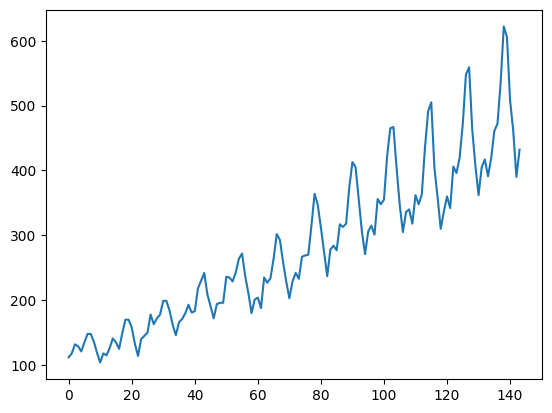

In [4]:
dataframe = pd.read_csv('https://raw.githubusercontent.com/jbrownlee/Datasets/master/airline-passengers.csv', usecols=[1], engine='python')
df = dataframe.values
df = df.astype('float32')
plt.plot(df)
plt.show()

In [5]:
scaler = MinMaxScaler(feature_range=(0,1))
df = scaler.fit_transform(df)
df[: 5]
df.shape

(144, 1)

In [6]:
train_size = int(len(df) * 0.67)
test_size = len(df) - train_size

train, test = df[0:train_size, :], df[train_size:len(df), :]
print(type(train), len(test))

<class 'numpy.ndarray'> 48


In [7]:
look_back = 1 
def create_dataset(dataset, look_back=1):
    dataX, dataY = [], []
    for i in range(len(dataset) - look_back - 1):
        dataX.append(dataset[i:(i + look_back), 0])
        dataY.append(dataset[i + look_back, 0])
    return np.array(dataX), np.array(dataY)

trainX, trainY = create_dataset(dataset=train, look_back=look_back)
testX, testY = create_dataset(test, look_back=look_back)


In [45]:
trainX = trainX.reshape(94,1)
testX = testX.reshape(46,1)
trainY = trainY.reshape(94)
testY = testY.reshape(46)

n=100, depth=1, lr=0.1 -> acc=6566.5595
n=100, depth=1, lr=0.5 -> acc=6457.1824
n=100, depth=1, lr=0.6 -> acc=6335.4108
n=100, depth=1, lr=0.7 -> acc=6372.5980
n=100, depth=1, lr=0.9 -> acc=6399.5040
n=100, depth=1, lr=1 -> acc=6314.1608
n=100, depth=2, lr=0.1 -> acc=6656.8054
n=100, depth=2, lr=0.5 -> acc=6304.7610
n=100, depth=2, lr=0.6 -> acc=6343.4153
n=100, depth=2, lr=0.7 -> acc=6319.0929
n=100, depth=2, lr=0.9 -> acc=6281.5900
n=100, depth=2, lr=1 -> acc=6309.0720
n=130, depth=1, lr=0.1 -> acc=6471.8455
n=130, depth=1, lr=0.5 -> acc=6326.9344
n=130, depth=1, lr=0.6 -> acc=6209.2855
n=130, depth=1, lr=0.7 -> acc=6398.4058
n=130, depth=1, lr=0.9 -> acc=6406.6017
n=130, depth=1, lr=1 -> acc=6396.3854
n=130, depth=2, lr=0.1 -> acc=6521.9324
n=130, depth=2, lr=0.5 -> acc=6330.6392
n=130, depth=2, lr=0.6 -> acc=6298.0809
n=130, depth=2, lr=0.7 -> acc=6313.2013
n=130, depth=2, lr=0.9 -> acc=6294.3215
n=130, depth=2, lr=1 -> acc=6317.4294
n=140, depth=1, lr=0.1 -> acc=6459.4114
n=140, d

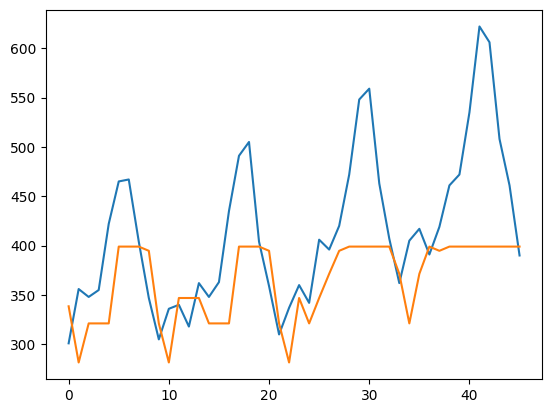

In [61]:
from xgboost import XGBRegressor
from itertools import product

param_grid = {
    "n_estimators": [100, 130, 140, 150],
    "max_depth": [1, 2],
    "learning_rate": [0.1, 0.5, 0.6, 0.7, 0.9, 1],
} 

best_acc = 10000000
best_param = {}

for n, d, lr in product(param_grid["n_estimators"], param_grid["max_depth"], param_grid["learning_rate"]):
    model = XGBRegressor(n_estimators=n, max_depth=d, learning_rate=lr,random_state= 42)
    model.fit(trainX, trainY)
    pred = model.predict(testX)

    acc = mean_squared_error(testY, pred)

    if acc < best_acc:
        best_acc = acc
        best_param = {"n_estimators": n, "max_depth": d, "learning_rate": lr}
    print(f"n={n}, depth={d}, lr={lr} -> acc={acc:.4f}")
print(f"\nBest: {best_param}, Accuracy: {best_acc:.4f}")

model = XGBRegressor(n_estimators=best_param["n_estimators"], max_depth=best_param["max_depth"], learning_rate=best_param["learning_rate"], random_state=42)
model.fit(trainX, trainY )
predictions= model.predict(testX)

plt.plot(testY)
plt.plot(predictions)
plt.show()

In [70]:
import os
import joblib

os.makedirs("models/", exist_ok=True)

joblib.dump(model, "src/models/xgb_v1.pkl")



['src/models/xgb_v1.pkl']

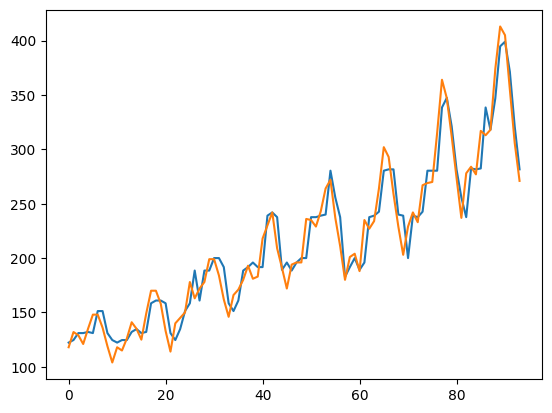

In [71]:
m_v1 = joblib.load("src/models/xgb_v1.pkl")
p = m_v1.predict(trainX)

plt.plot(p)
plt.plot(trainY)
plt.show()

In [9]:
# reshape input to be [samples, time steps, features]
trainX = np.reshape(trainX, (trainX.shape[0], 1, trainX.shape[1]))
testX = np.reshape(testX, (testX.shape[0], 1, testX.shape[1]))

In [10]:
# create and fit the LSTM network
model = Sequential()
model.add(LSTM(4, input_shape=(1, look_back)))
model.add(Dense(1))
model.compile(loss='mean_squared_error', optimizer='adam')
model.fit(trainX, trainY, epochs=100, batch_size=1, verbose=2)

c:\Users\sou1n\AppData\Local\Programs\Python\Python311\Lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Epoch 1/100
94/94 - 2s - 20ms/step - loss: 0.0317
Epoch 2/100
94/94 - 0s - 3ms/step - loss: 0.0149
Epoch 3/100
94/94 - 0s - 2ms/step - loss: 0.0113
Epoch 4/100
94/94 - 0s - 2ms/step - loss: 0.0102
Epoch 5/100
94/94 - 0s - 2ms/step - loss: 0.0092
Epoch 6/100
94/94 - 0s - 2ms/step - loss: 0.0082
Epoch 7/100
94/94 - 0s - 2ms/step - loss: 0.0072
Epoch 8/100
94/94 - 0s - 2ms/step - loss: 0.0062
Epoch 9/100
94/94 - 0s - 2ms/step - loss: 0.0052
Epoch 10/100
94/94 - 0s - 2ms/step - loss: 0.0043
Epoch 11/100
94/94 - 0s - 2ms/step - loss: 0.0036
Epoch 12/100
94/94 - 0s - 2ms/step - loss: 0.0030
Epoch 13/100
94/94 - 0s - 2ms/step - loss: 0.0026
Epoch 14/100
94/94 - 0s - 2ms/step - loss: 0.0023
Epoch 15/100
94/94 - 0s - 2ms/step - loss: 0.0022
Epoch 16/100
94/94 - 0s - 2ms/step - loss: 0.0021
Epoch 17/100
94/94 - 0s - 2ms/step - loss: 0.0021
Epoch 18/100
94/94 - 0s - 2ms/step - loss: 0.0020
Epoch 19/100
94/94 - 0s - 2ms/step - loss: 0.0020
Epoch 20/100
94/94 - 0s - 2ms/step - loss: 0.0020
Epoch 21

In [11]:
# make predictions
trainPredict = model.predict(trainX)
testPredict = model.predict(testX)
# invert predictions
trainPredict = scaler.inverse_transform(trainPredict)
trainY = scaler.inverse_transform([trainY])
testPredict = scaler.inverse_transform(testPredict)
testY = scaler.inverse_transform([testY])
# calculate root mean squared error
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 66ms/step
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 16ms/step
Train Score: 22.72 RMSE
Test Score: 50.90 RMSE


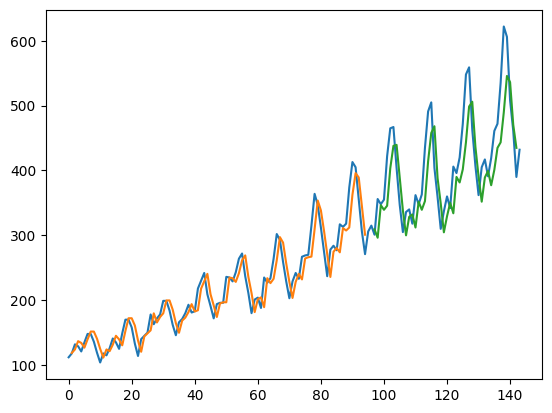

In [12]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(df)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
# shift test predictions for plotting
testPredictPlot = np.empty_like(df)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back*2)+1:len(df)-1, :] = testPredict
# plot baseline and predictions
plt.plot(scaler.inverse_transform(df))
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

In [13]:
x = np.linspace(0, 100, 1000)
data = np.sin(x)
data.shape

(1000,)

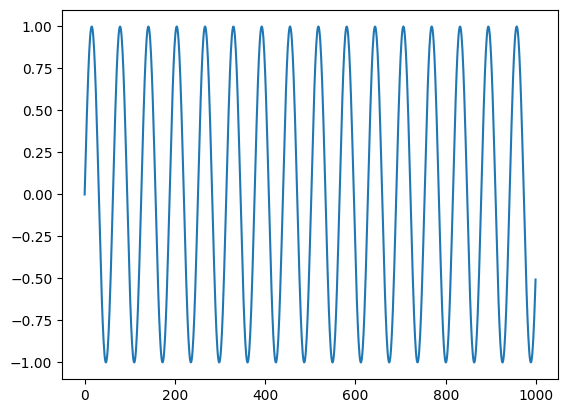

In [14]:
plt.plot(data)
plt.show()

In [15]:
def create_sequences(data, seq_len):
    x = []
    y = []
    length = len(data)

    for i in range(length-seq_len):
        x.append(data[i: i+seq_len])
        y.append(data[i+seq_len])

    x = np.array(x)
    y = np.array(y)

    x = x.reshape(x.shape[0], x.shape[1], 1)
    y = y.reshape(x.shape[0], 1)
    return x, y 


In [16]:
x_train, y_train = create_sequences(data, 30)

In [17]:
class SimpleLSTM(nn.Module):
    def __init__(self):
        super().__init__()
        self.lstm = nn.LSTM(input_size=1, hidden_size=32, batch_first=True)
        self.linear = nn.Linear(32, 1)
    
    def forward(self, x):
        output, (hidden, cell) = self.lstm(x)

        last = output[:, -1, :]
        pred = self.linear(last)

        return pred


In [18]:
x_train = torch.FloatTensor(x_train)
y_train = torch.FloatTensor(y_train)


In [19]:
y_train.shape

torch.Size([970, 1])

In [20]:
model = SimpleLSTM()
criteria = nn.MSELoss()
optimizer = torch.optim.Adam( model.parameters(), lr= 0.001 )

for epoch in range(100):

    optimizer.zero_grad()

    predictions = model(x_train)

    loss = criteria(predictions, y_train)

    loss.backward()

    optimizer.step()

    if epoch % 10 == 0:
        print(f"epoch {epoch} loss = {loss.item()}")


epoch 0 loss = 0.6059970855712891
epoch 10 loss = 0.527066171169281
epoch 20 loss = 0.4601786434650421
epoch 30 loss = 0.3852877616882324
epoch 40 loss = 0.28593653440475464
epoch 50 loss = 0.187077596783638
epoch 60 loss = 0.11026468127965927
epoch 70 loss = 0.03424074500799179
epoch 80 loss = 0.014788514003157616
epoch 90 loss = 0.006842002272605896


In [21]:
model.eval()

SimpleLSTM(
  (lstm): LSTM(1, 32, batch_first=True)
  (linear): Linear(in_features=32, out_features=1, bias=True)
)

In [22]:
with torch.no_grad():
    predictions = model(x_train)


In [23]:
predictions = predictions.numpy()
actual = y_train.numpy()

predictions.shape

(970, 1)

In [24]:
actual.shape

(970, 1)

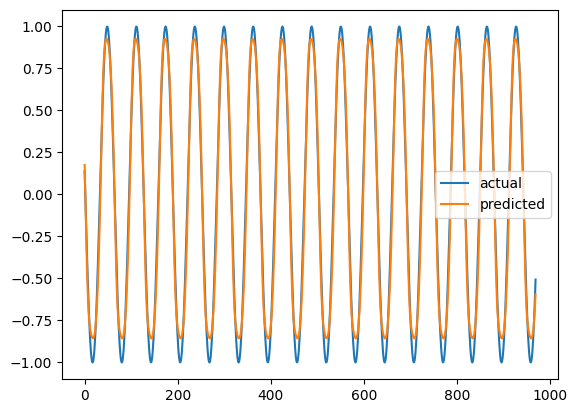

In [25]:
plt.plot(actual, label = "actual")
plt.plot(predictions, label= "predicted")
plt.legend()
plt.show()
